# Práctica evaluación módulo 'Machine Learning y Deep Learning

## 0. Configuración Notebook

### Importación librerías

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

### Definición constantes

In [5]:
DATA_DIR_RAW = '../../data/raw'

In [6]:
DATASET = f'{DATA_DIR_RAW}/dataset_practica_final.csv'
DATASET

'../../data/raw/dataset_practica_final.csv'

### Definición funciones

In [10]:
def compare_scores(model_list, y_test, X_test):
    '''
    muestra un dataframe con índice por modelo y columnas por métrica, valores el valor de la métrica
    '''
    pass

In [5]:
def plot_ROC(model_list, y_test, X_test):
    '''
    saca una figura con un subplot por modelo del ROC
    '''
    pass

In [6]:
def plot_confusion_matrix(model_list, y_test, X_test):
    '''
    saca una figura con un subplot por modelo de la confusion_matrix
    '''
    pass

## 1. Carga y pre-procesamiento de datos

### Carga y copia

In [7]:
dset = pd.read_csv(DATASET)
dset_cp = dset.copy()

### Inspección

## Variables

| Nombre Variable                  | Descripción                                              |
| -------------------------------- | -------------------------------------------------------- |
| `hotel`                          | Tipo de hotel: City Hotel o Resort Hotel                 |
| `is_canceled`                    | Variable objetivo: 1 si fue cancelado, 0 si no           |
| `lead_time`                      | Días entre la reserva y la fecha de llegada              |
| `arrival_date_year`              | Año de llegada                                           |
| `arrival_date_month`             | Mes de llegada                                           |
| `arrival_date_week_number`       | Número de la semana del año                              |
| `arrival_date_day_of_month`      | Día del mes de llegada                                   |
| `stays_in_weekend_nights`        | Noches de fin de semana reservadas                       |
| `stays_in_week_nights`           | Noches entre semana reservadas                           |
| `adults`                         | Número de adultos                                        |
| `children`                       | Número de niños                                          |
| `babies`                         | Número de bebés                                          |
| `meal`                           | Tipo de comida reservada                                 |
| `country`                        | País de origen del cliente                               |
| `market_segment`                 | Canal de marketing (online, offline, grupos...)          |
| `distribution_channel`           | Canal de distribución (directo, TA/TO...)                |
| `is_repeated_guest`              | 1 si el cliente ha estado anteriormente                  |
| `previous_cancellations`         | Nº de cancelaciones anteriores                           |
| `previous_bookings_not_canceled` | Nº de reservas previas no canceladas                     |
| `reserved_room_type`             | Tipo de habitación reservada                             |
| `assigned_room_type`             | Tipo de habitación asignada                              |
| `booking_changes`                | Nº de cambios en la reserva                              |
| `deposit_type`                   | Tipo de depósito: No Deposit, Refundable, etc.           |
| `agent`                          | ID del agente (puede ser nulo)                           |
| `company`                        | ID de la empresa (puede ser nulo)                        |
| `days_in_waiting_list`           | Días en lista de espera                                  |
| `customer_type`                  | Tipo de cliente: Transient, Group, etc.                  |
| `adr`                            | Average Daily Rate (precio promedio por noche)           |
| `required_car_parking_spaces`    | Plazas de parking solicitadas                            |
| `total_of_special_requests`      | Nº de peticiones especiales                              |
| `reservation_status`             | Estado final de la reserva: Check-Out, Canceled, No-Show |
| `reservation_status_date`        | Fecha en que se actualizó el estado                      |

### *Cosas a ver*:
- si está balanceado
- identificar outlayers
- identificar datos faltantes
- sacar correlaciones
- sacar pca 


In [8]:
dset.info()
# reservation_status y reservation_status_date fuera, en tanto que la primera da información que duplica o es posterior al target y la segunda es un atributo de la primera

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [100]:
dset_cp.drop(['reservation_status', 'reservation_status_date'], axis=1, inplace=True)

In [9]:
#MANUEL
dset.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [15]:
#MANUEL
# mostrar el porcentaje exacto de cancelaciones vs no cancelaciones
porcentajes = dset['is_canceled']. value_counts(normalize=True) * 100
print("Distribución de la variable objetivo (%):")
print(porcentajes)
print('La métrica aquí para observar será F1-Score o AUC-ROC. Accuracy no será una buena métrica porque si el modelo dice siempre "no cancela", acertaría el 63% de las veces sin saber nada ')

Distribución de la variable objetivo (%):
is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64
La métrica aquí para observar será F1-Score o AUC-ROC. Accuracy no será una buena métrica porque si el modelo dice siempre "no cancela", acertaría el 63% de las veces sin saber nada 


In [18]:
#MANUEL
# Columnas que tienen valores nulos y cuántos tienen
nulos = dset.isna().sum()
columnas_con_nulos = nulos[nulos > 0]
print("\nColumnas con valores nulos:")
print(columnas_con_nulos)

# Filas duplicadas
print(f"\nFilas duplicadas exactas: {dset.duplicated().sum()}")


Columnas con valores nulos:
children         4
country        488
agent        16340
company     112593
dtype: int64

Filas duplicadas exactas: 31994


In [19]:
print('Eliminaremos company. Demasiados nulos')
print('Con agent, faltan pocos nulos, pero un valor nulo no es un error, significa que el cliente reservó directamente sin usar una agencia. Entonces imputaremos los nulos con el valor 0 para indicar "Reserva Directa".')
print('Demasiadas filas duplicadas. Es mejor eliminar los duplicados, si los mantenemos, corremos el riesgo de fuga de datos al hacer train_test_split')

Eliminaremos company. Demasiados nulos
Con agent, faltan pocos nulos, pero un valor nulo no es un error, significa que el cliente reservó directamente sin usar una agencia. Entonces imputaremos los nulos con el valor 0 para indicar "Reserva Directa".
Demasiadas filas duplicadas. Es mejor eliminar los duplicados, si los mantenemos, corremos el riesgo de fuga de datos al hacer train_test_split


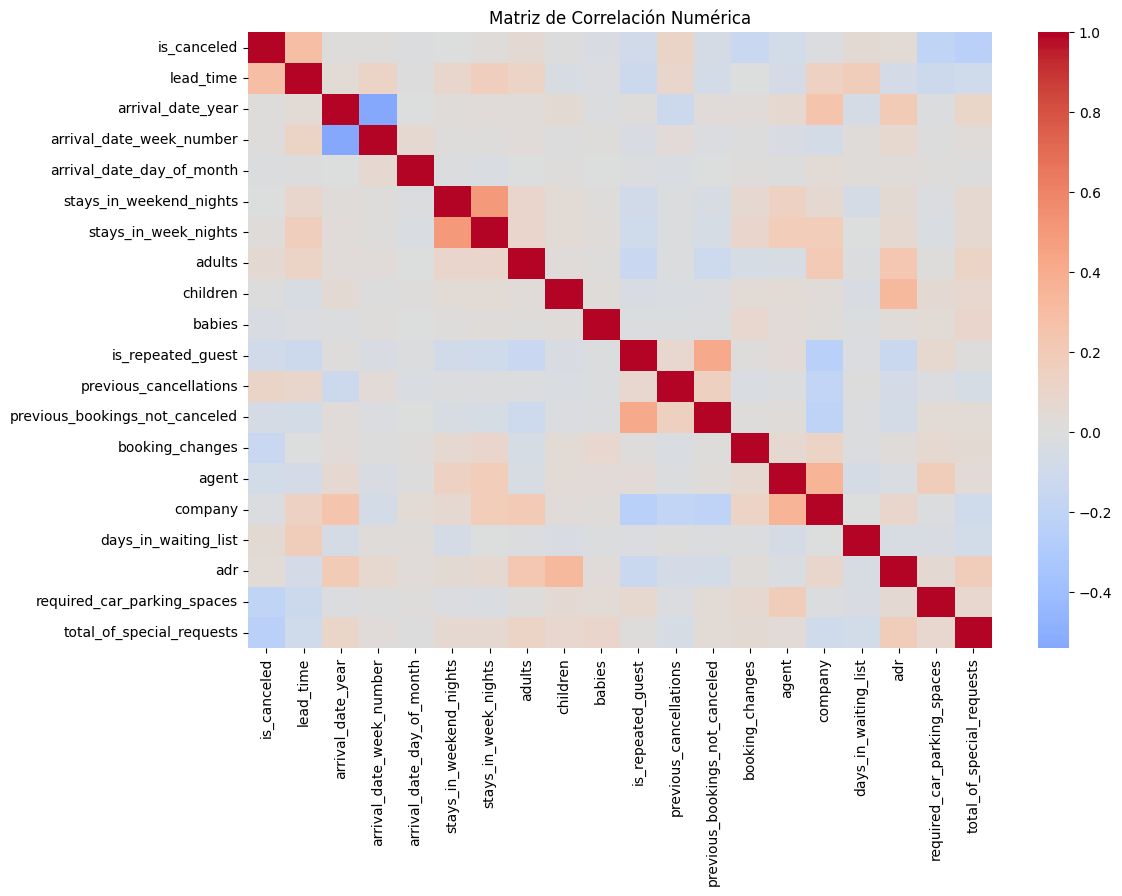

In [12]:
#MANUEL
# Solo columnas numéricas para evitar errores
df_numerico = dset.select_dtypes(include=['number'])

plt.figure(figsize=(12, 8))
# mapa de calor (sin números para no saturar la vista inicial)
sns.heatmap(df_numerico.corr(), annot=False, cmap='coolwarm', center=0)
plt.title("Matriz de Correlación Numérica")
plt.show()

In [14]:
dset.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [95]:
dset['is_canceled'].value_counts()
# el dataset está balanceado

is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [98]:
dset.isna().sum()[dset.isna().sum() > 0]
# country: sustituir na por 'unknown'. muchos menos na que na: vale la pena conservarla, ya que a pesar de los na sigue aportando iformación
# agent: ver análisis más abajo (se quita)
# company: más na que no na (muchos más): se elimina. no aporta información
# en children solamente hay 4 filas sin valores: se va a asignar la mediana

children         4
country        488
agent        16340
company     112593
dtype: int64

In [102]:
dset_cp.drop(['company'], axis=1, inplace=True)

In [166]:
dset_cp['children'] = dset_cp['children'].fillna(dset_cp['children'].median())

In [168]:
dset_cp['country'] = dset_cp['country'].fillna('unknown')

/tmp/ipykernel_461/2660218604.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


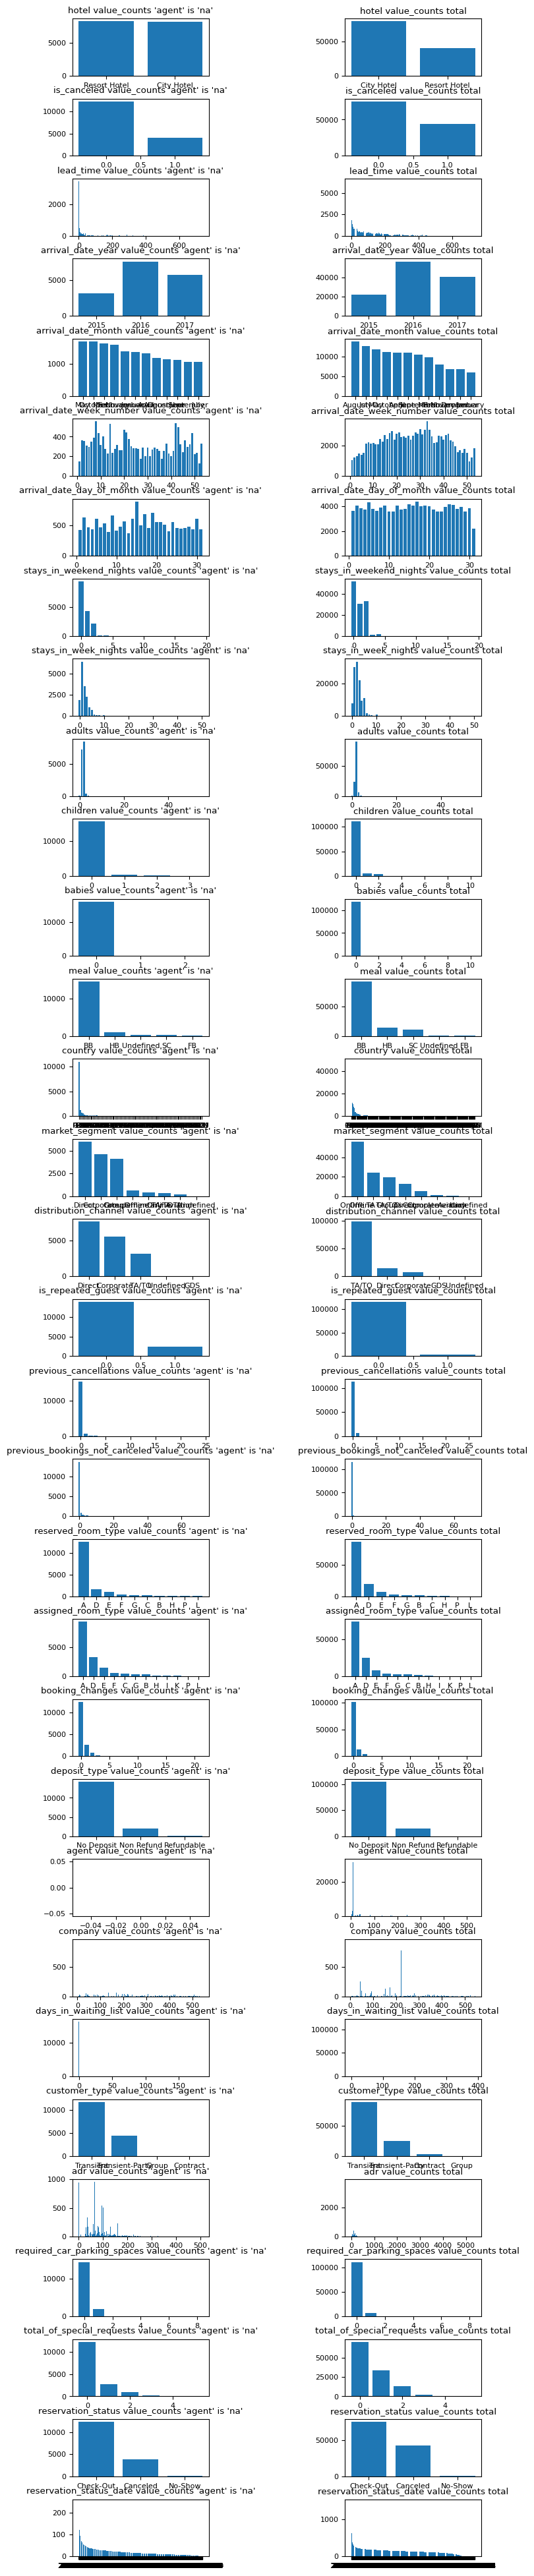

In [105]:
i=0
fig, ax = plt.subplots(nrows = len(dset.columns), ncols=2, figsize=(8,50))
plt.subplots_adjust(hspace=0.4, wspace=1)
plt.rc({'font.size':6})
for c in dset.columns:
    vc_agent_is_na = dset[dset['agent'].isna()][c].dropna().value_counts()
    ax[i,0].bar(vc_agent_is_na.index, vc_agent_is_na)
    ax[i,0].set_title(f"{c} value_counts 'agent' is 'na'")
    vc_total = dset[c].dropna().value_counts()
    ax[i,1].bar(vc_total.index, vc_total)
    ax[i,1].set_title(f"{c} value_counts total")
    i +=1
fig.show()

# se comparan los value conuts de las columnas dependiendo se si se filtran fuera las filas con 'agent' a 'na' o no, por ver si los 'na' están uniformemente distribuidos o no, 
# es deicir, si el valor 'na' en 'agent' contiene información por sesgo
# se ve que en algunas variables claramente lo tiene. Entre ellas en is_canceled, que es el target. Es por ello que se elimina la variable 'agent'

In [106]:
dset_cp.drop(['agent'], axis=1, inplace=True)

In [193]:
dset.babies.value_counts()

babies
0     118473
1        900
2         15
10         1
9          1
Name: count, dtype: int64

In [197]:
dset.is_repeated_guest.value_counts()
# is_repeatied_guest es categórica

is_repeated_guest
0    115580
1      3810
Name: count, dtype: int64

In [107]:
dset_cp.head().T

,0,1,2,3,4
hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel
is_canceled,0,0,0,0,0
lead_time,342,737,7,13,14
arrival_date_year,2015,2015,2015,2015,2015
arrival_date_month,July,July,July,July,July
arrival_date_week_number,27,27,27,27,27
arrival_date_day_of_month,1,1,1,1,1
stays_in_weekend_nights,0,0,0,0,0
stays_in_week_nights,0,0,1,1,2
adults,2,2,1,1,2


In [177]:
[f'{year}: {len(dset[(dset.arrival_date_year==year) & (dset.is_canceled==1)])/len(dset[(dset.arrival_date_year==year) & (dset.is_canceled==0)]):.2f}' for year in dset.arrival_date_year.unique()]
# para predecir valores interesan variables cíclicas en el tiempo, no pasadas; es por ello que el año no ofrece información para la predicción. 
# Sí para el análisis de los datos, por si hay un sesgo dependiendo del año delque se tomaron los datos
# se observa que no es así (oscila 4% arriba 4% abajo)
# nota: despuués se ha visto que esta operación se hubiese podido hacer con groupby y transform, pero ahora ya está hecho

['2015: 0.59', '2016: 0.56', '2017: 0.63']

In [ ]:
dset_cp.drop('arrival_date_year', axis=1, inplace=True)

In [138]:
# teniendo mes y día la semana es redundante. El día es importante porqué el perfil de cliente es lógico que pueda variar dependiendo de si es fin de semana o no. El mes también, por la estaionalidad
dset_cp.drop('arrival_date_week_number', axis=1, inplace=True)

In [156]:
categorical_fields = [c for c in dset_cp.columns if dset_cp[c].dtype==object]
for c in categorical_fields:
    print(f'{c}: {dset[c].value_counts().count()}')
# valiables no numéricas, se tendrán que categorizar, abajo el número de categorías de cada una

hotel: 2
arrival_date_month: 12
meal: 5
country: 177
market_segment: 8
distribution_channel: 5
reserved_room_type: 10
assigned_room_type: 12
deposit_type: 3
customer_type: 4


In [162]:
# se convierten los campos a catgorías, se toman sus códigos numéridos (.cat.codes) y se sustitye a los string originales por ellos
for c in categorical_fields:
    dset_cp[c] = dset_cp[c].astype('category').cat.codes
dset_cp[categorical_fields].head().T

,0,1,2,3,4
hotel,1,1,1,1,1
arrival_date_month,5,5,5,5,5
meal,0,0,0,0,0
country,135,135,59,59,59
market_segment,3,3,3,2,6
distribution_channel,1,1,1,0,3
reserved_room_type,2,2,0,0,0
assigned_room_type,2,2,2,0,0
deposit_type,0,0,0,0,0
customer_type,2,2,2,2,2


In [169]:
dset_cp.shape

(119390, 26)

In [173]:
dset_cp.isna().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_month                0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests         0
dtype: int64

In [174]:
dset_cp.dtypes

hotel                                int8
is_canceled                         int64
lead_time                           int64
arrival_date_month                   int8
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                 int8
country                             int16
market_segment                       int8
distribution_channel                 int8
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                   int8
assigned_room_type                   int8
booking_changes                     int64
deposit_type                         int8
days_in_waiting_list                int64
customer_type                        int8
adr                               

In [176]:
dset_cp.describe().T

,count,mean,std,min,25%,50%,75%,max
hotel,119390.0,0.335539,0.472181,0.00,0.00,0.000,1.0,1.0
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_month,119390.0,5.490544,3.535075,0.00,2.00,6.000,8.0,11.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119390.0,0.103886,0.398555,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [202]:
# para quitar outlayers, se va a aplicar un filtro por la estadística z = (x - mean)/std en los datos que no son categóricos
categorical_fields = categorical_fields + ['is_canceled', 'is_repeated_guest']
numeric_fields = [c for c in dset_cp.columns if c not in categorical_fields]
numeric_fields

['lead_time',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'booking_changes',
 'days_in_waiting_list',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests']

In [218]:
# normalmente se considera outlier lo que tenga una estadística Z más allá de -3 +3  ##########  PARÁMETRO filter_val #########
Z_stat = pd.DataFrame()
filter_val = 5
dset_len = len(dset_cp)
for c in numeric_fields:
    Z_stat[c] = dset_cp[c].transform(lambda x: abs(x - x.mean())/x.std() < filter_val)
    print(f'{c}: {1 - Z_stat[c].sum()/dset_len:.1%} outliers')

lead_time: 0.0% outliers
arrival_date_day_of_month: 0.0% outliers
stays_in_weekend_nights: 0.2% outliers
stays_in_week_nights: 0.3% outliers
adults: 0.0% outliers
children: 0.1% outliers
babies: 0.8% outliers
previous_cancellations: 0.2% outliers
previous_bookings_not_canceled: 0.5% outliers
booking_changes: 0.5% outliers
days_in_waiting_list: 0.8% outliers
adr: 0.0% outliers
required_car_parking_spaces: 0.0% outliers
total_of_special_requests: 0.0% outliers


In [219]:
# se filtran fuera los outliers
dset_cp_fil = pd.concat([dset_cp[numeric_fields][Z_stat], dset_cp[categorical_fields]], axis=1).dropna()
print(f'{(len(dset_cp) - len(dset_cp_fil))/len(dset_cp):.1%} filas filtradas fuera')
print(dset_cp_fil.columns)

3.1% filas filtradas fuera
Index(['lead_time', 'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_waiting_list', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests', 'hotel',
       'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'is_canceled', 'is_repeated_guest'],
      dtype='object')


In [220]:
dset_cp_fil.head().T

,0,2,3,4,5
lead_time,342.0,7.0,13.0,14.0,14.0
arrival_date_day_of_month,1.0,1.0,1.0,1.0,1.0
stays_in_weekend_nights,0.0,0.0,0.0,0.0,0.0
stays_in_week_nights,0.0,1.0,1.0,2.0,2.0
adults,2.0,1.0,1.0,2.0,2.0
children,0.0,0.0,0.0,0.0,0.0
babies,0.0,0.0,0.0,0.0,0.0
previous_cancellations,0.0,0.0,0.0,0.0,0.0
previous_bookings_not_canceled,0.0,0.0,0.0,0.0,0.0
booking_changes,3.0,0.0,0.0,0.0,0.0


### Pre-procesiamiento

## *cosas a hacer:*
- quitar variables no importantes o que distorsionan
- quitar o imputar datos
- estandarizar
- codificar categóricas

## 2. Entrenamiento (incluye selección de hiperparámetros)

### 2.1 Logistic Regression

### 2.2 DecisionTree

### 2.3 Random Forest

### 2.4 XGBoost

### 2.5 Multilayer Neural Network

## 3. Comparativa Modelos